In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("../data/PSCompPars.csv", comment="#")
df.shape

(6298, 320)

In [3]:
host_features = [
    "st_mass",
    "st_rad",
    "st_teff",
    "st_lum",
    "st_met",
    "st_age"
]

df[host_features].info()

<class 'pandas.DataFrame'>
RangeIndex: 6298 entries, 0 to 6297
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   st_mass  6266 non-null   float64
 1   st_rad   5958 non-null   float64
 2   st_teff  5984 non-null   float64
 3   st_lum   5962 non-null   float64
 4   st_met   5636 non-null   float64
 5   st_age   4846 non-null   float64
dtypes: float64(6)
memory usage: 295.3 KB


In [7]:
planet_classes = pd.read_csv(
    "../data/processed/planet_classes.csv"
)

In [8]:
df["planet_class"] = planet_classes["planet_class"]
df["planet_class_name"] = planet_classes["planet_class_name"]

/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_48590/3835997944.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["planet_class"] = planet_classes["planet_class"]
/var/folders/zq/8j1g8nx571l4jtmw_t1d4njw0000gn/T/ipykernel_48590/3835997944.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["planet_class_name"] = planet_classes["planet_class_name"]


## Host-Star Association Analysis

In [9]:
df.groupby("planet_class_name")[
    [
        "st_mass",
        "st_rad",
        "st_teff",
        "st_lum"
    ]
].median()

,st_mass,st_rad,st_teff,st_lum
planet_class_name,,,,
Intermediate Low-Density Planets,0.915,0.907000,5531.0,-0.16141
Low-Density Giants,1.040,1.176975,5706.5,0.19000
Massive Dense Giants,1.060,1.368000,5466.5,0.35595
Small Dense Planets,0.870,0.840000,5375.0,-0.27856


In [11]:
from scipy.stats import kruskal

groups = [
    df[df["planet_class_name"] == c]["st_mass"].dropna()
    for c in df["planet_class_name"].unique()
]

kruskal(*groups)


KruskalResult(statistic=np.float64(490.0192342447297), pvalue=np.float64(6.943932315445705e-106))

 p value is 0.000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000694

reject the null hypothesis immediately.

Host-star mass differs significantly across the four planetary archetypes.


| Host-Star Property              | Kruskal Statistic |       p-value |
| ------------------------------- | ----------------: | ------------: |
| Stellar Mass (`st_mass`)        |             490.0 | 6.94 × 10⁻¹⁰⁶ |
| Stellar Temperature (`st_teff`) |             200.1 |  3.95 × 10⁻⁴³ |
| Stellar Radius (`st_rad`)       |             950.4 | 1.03 × 10⁻²⁰⁵ |
| Stellar Luminosity (`st_lum`)   |             757.1 | 8.85 × 10⁻¹⁶⁴ |


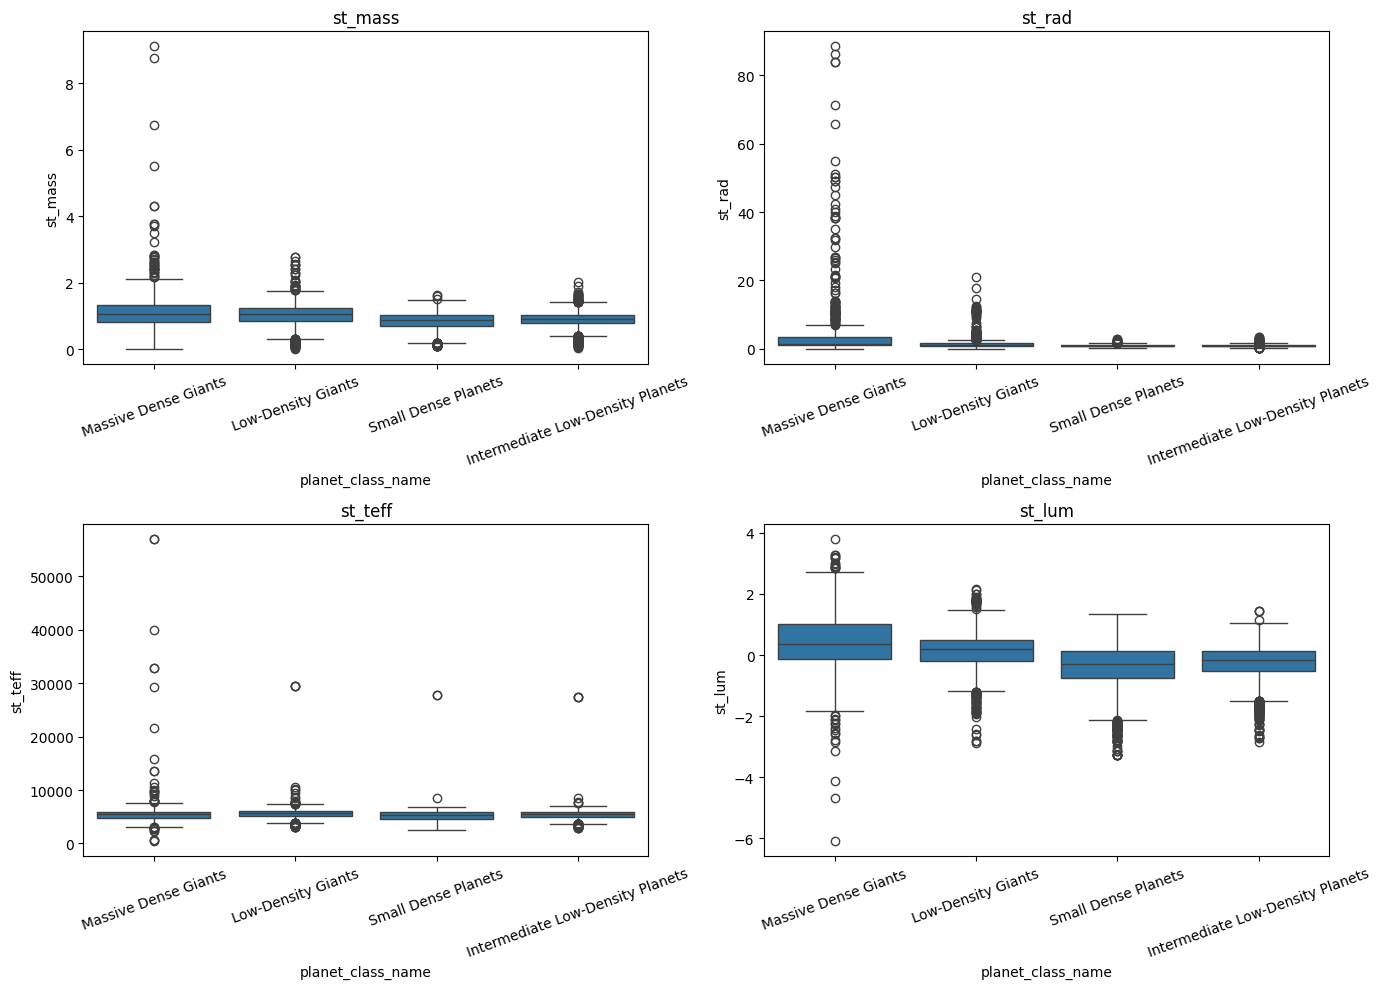

In [15]:
host_features = [
    "st_mass",
    "st_rad",
    "st_teff",
    "st_lum"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feature in zip(axes.flatten(), host_features):
    sns.boxplot(
        data=df,
        x="planet_class_name",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Host-star properties differ significantly between archetypes.

## Host-Star Clustering Experiment

In [16]:
cluster_features = [
    "pl_rade",
    "pl_bmasse",
    "pl_dens",
    "pl_orbsmax",
    "st_mass",
    "st_rad",
    "st_teff",
    "st_lum"
]

df_host = df[cluster_features].copy()

df_host.shape

(6298, 8)

In [18]:
df_host.isna().sum()

pl_rade        60
pl_bmasse      41
pl_dens       151
pl_orbsmax    435
st_mass        32
st_rad        340
st_teff       314
st_lum        336
dtype: int64

#### HANDLING MISSING VALUES USING MEDIAN IMPUTATION

In [19]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

df_host_imputed = pd.DataFrame(
    imputer.fit_transform(df_host),
    columns=df_host.columns
)

df_host_imputed.shape

(6298, 8)

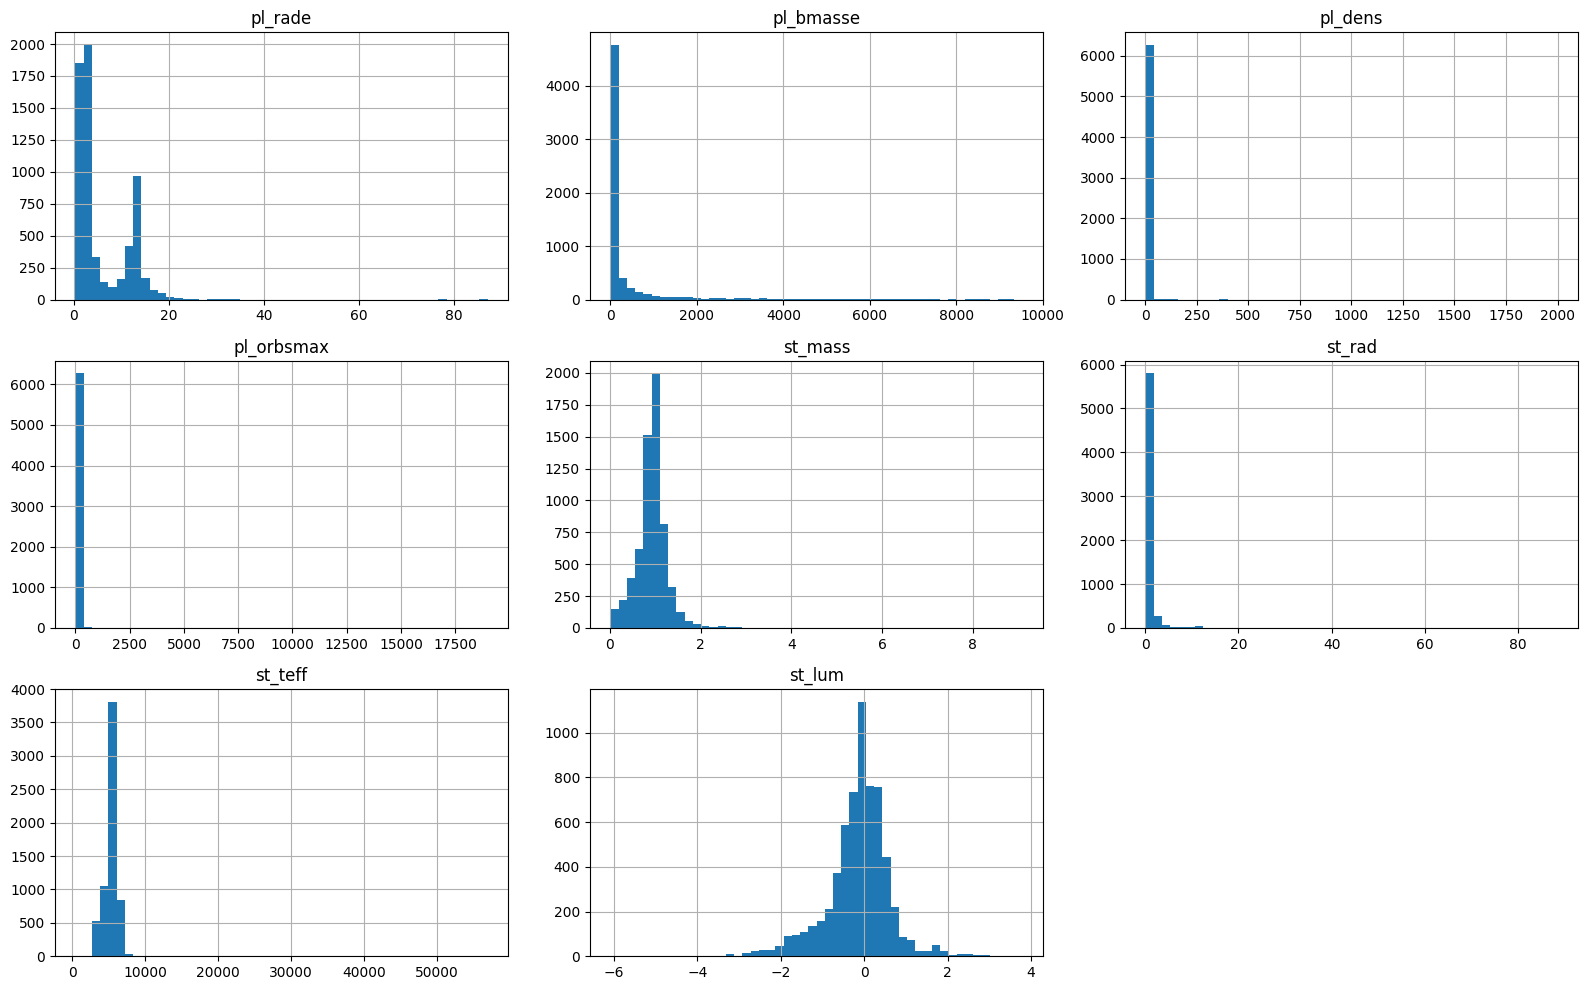

In [20]:
df_host_imputed.hist(
    figsize=(16,10),
    bins=50
)

plt.tight_layout()
plt.show()

#### APPLYING LOG TRANSFORMATIONS

In [21]:
import numpy as np

df_cluster = df_host_imputed.copy()

df_cluster["log_pl_rade"] = np.log1p(df_cluster["pl_rade"])
df_cluster["log_pl_bmasse"] = np.log1p(df_cluster["pl_bmasse"])
df_cluster["log_pl_dens"] = np.log1p(df_cluster["pl_dens"])
df_cluster["log_pl_orbsmax"] = np.log1p(df_cluster["pl_orbsmax"])

df_cluster["log_st_rad"] = np.log1p(df_cluster["st_rad"])

In [22]:
clustering_features = [
    "log_pl_rade",
    "log_pl_bmasse",
    "log_pl_dens",
    "log_pl_orbsmax",
    "st_mass",
    "log_st_rad",
    "st_teff",
    "st_lum"
]

X_host = df_cluster[clustering_features]

X_host.head()

,log_pl_rade,log_pl_bmasse,log_pl_dens,log_pl_orbsmax,st_mass,log_st_rad,st_teff,st_lum
0,2.580217,8.500230,2.766319,0.778407,2.09,2.691921,4874.0,1.97823
1,2.587764,8.452295,2.694627,0.928219,2.78,3.427190,4213.0,2.42951
2,2.646175,7.031875,1.324419,0.573800,1.78,2.529721,4888.0,1.83992
3,2.602690,7.947916,2.192770,1.345212,0.97,0.657520,5338.0,-0.15273
4,2.674149,6.339896,0.815365,0.978326,1.08,0.756122,5750.0,0.09729


In [23]:
from sklearn.preprocessing import StandardScaler

scaler_host = StandardScaler()
X_host_scaled = scaler_host.fit_transform(X_host)

X_host_scaled.shape

(6298, 8)

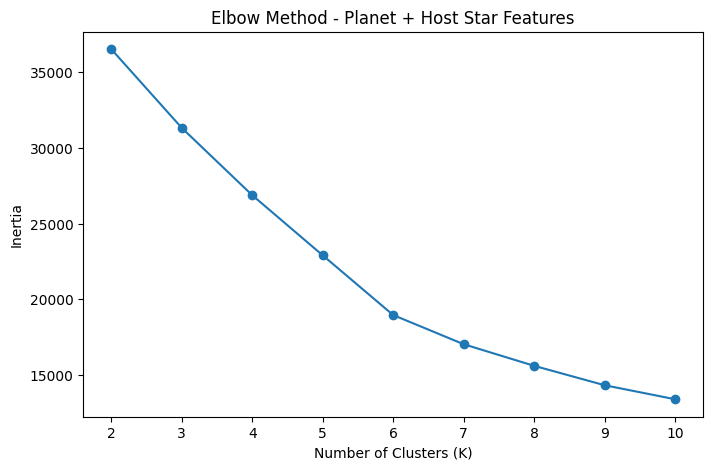

In [24]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_host_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2,11), inertia, marker="o")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Planet + Host Star Features")
plt.show()

In [25]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_host_scaled)

    score = silhouette_score(
        X_host_scaled,
        labels
    )

    scores.append(score)

print(scores)

[0.3979789081061723, 0.39426788348139935, 0.33569405919172396, 0.3438362083755176, 0.361670893959148, 0.3663769883916811, 0.34340195696015885, 0.2740755794631229, 0.27618116489608785]


cluester quality got worst best is only 0.398 but planet only was 0.517

- from elbow best k is 6

In [27]:
kmeans_host = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

host_labels = kmeans_host.fit_predict(X_host_scaled)
pd.Series(host_labels).value_counts().sort_index()

0    3119
1     342
2    1641
3     219
4      14
5     963
Name: count, dtype: int64

In [28]:
kmeans_host_4 = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

host_labels_4 = kmeans_host_4.fit_predict(X_host_scaled)

pd.Series(host_labels_4).value_counts().sort_index()

0    3220
1    1850
2     243
3     985
Name: count, dtype: int64

In [29]:
host_clustered = df_cluster.copy()

host_clustered["cluster"] = host_labels_4

host_clustered.groupby("cluster")[
    [
        "pl_rade",
        "pl_bmasse",
        "pl_dens",
        "pl_orbsmax",
        "st_mass",
        "st_rad",
        "st_teff",
        "st_lum"
    ]
].median()

,pl_rade,pl_bmasse,pl_dens,pl_orbsmax,st_mass,st_rad,st_teff,st_lum
cluster,,,,,,,,
0,2.29,6.040000,2.81,0.10233,0.9500,0.95,5649.59,-0.06793
1,12.80,357.549800,0.88,0.22370,1.0225,1.07,5659.50,0.06000
2,13.10,994.802914,2.43,1.44800,1.5700,8.56,4860.00,1.58115
3,1.96,4.740000,3.28,0.06680,0.5490,0.53,3811.00,-1.24232


Adding host-star characteristics altered the clustering structure obtained from planetary properties alone. While broad planetary archetypes remained visible, host-star attributes introduced additional separation, particularly among small planets and giant planets. Small dense planets split according to stellar environment, and massive giant planets became associated with distinct high-radius, high-luminosity host stars. These results suggest that host-star characteristics meaningfully influence planetary archetype formation and should be considered when defining exoplanet populations.

In [30]:
pd.crosstab(
    planet_classes["planet_class_name"],
    host_labels_4,
    normalize="index"
).round(3)

col_0,0,1,2,3
planet_class_name,,,,
Intermediate Low-Density Planets,0.807,0.018,0.000,0.175
Low-Density Giants,0.027,0.886,0.049,0.037
Massive Dense Giants,0.003,0.756,0.228,0.014
Small Dense Planets,0.710,0.000,0.000,0.290


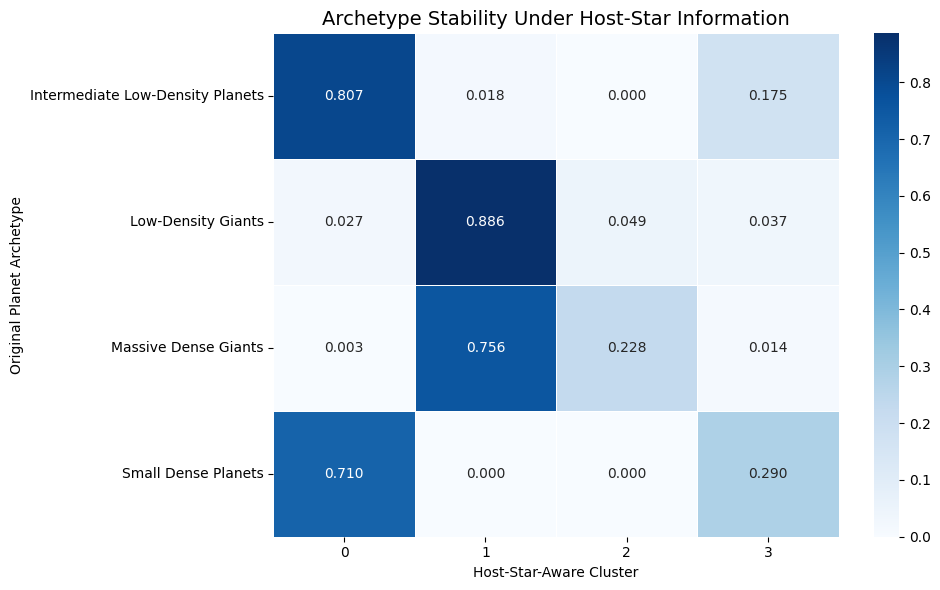

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

transition_matrix = pd.crosstab(
    planet_classes["planet_class_name"],
    host_labels_4,
    normalize="index"
).round(3)

plt.figure(figsize=(10,6))

sns.heatmap(
    transition_matrix,
    annot=True,
    cmap="Blues",
    fmt=".3f",
    linewidths=0.5
)

plt.title(
    "Archetype Stability Under Host-Star Information",
    fontsize=14
)

plt.xlabel("Host-Star-Aware Cluster")
plt.ylabel("Original Planet Archetype")

plt.tight_layout()

plt.savefig(
    "../assets/transition_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Low-Density Giants remain highly stable after incorporating host-star characteristics, whereas Small Dense Planets and Massive Dense Giants split into multiple host-star-aware clusters. This indicates that host-star properties contribute additional structure for some planetary archetypes but not all.

Cluster 0
Small-to-medium planets
Sun-like stars
Moderate densities
Cluster 1
Giant planets
Sun-like stars
Cluster 2
Massive giants
Large luminous stars
Cluster 3
Small dense planets
Cool low-mass stars

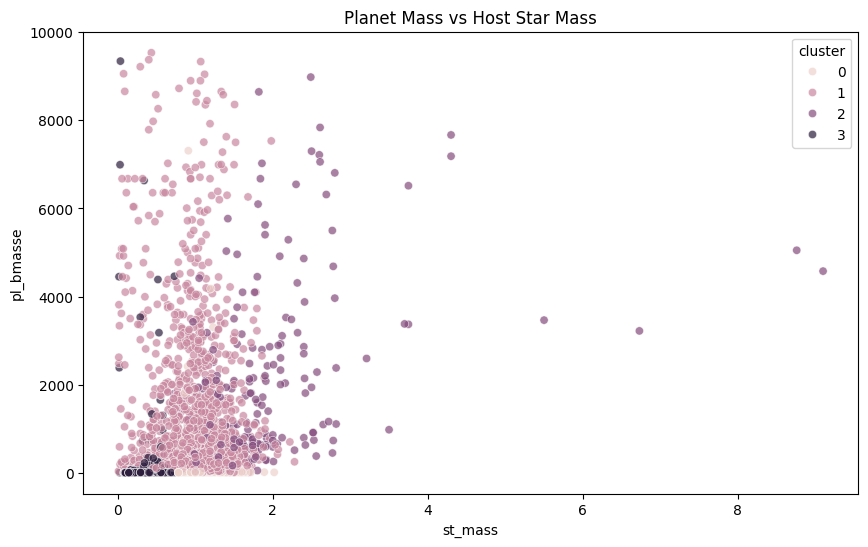

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=host_clustered,
    x="st_mass",
    y="pl_bmasse",
    hue="cluster",
    alpha=0.7
)

plt.title("Planet Mass vs Host Star Mass")
plt.show()


### Research Question

#### Do host-star characteristics meaningfully change planetary archetypes?

### Finding
- Low-Density Giants remained largely stable.
- Small Dense Planets split into two stellar-environment groups.
- Massive Dense Giants partially split into a high-luminosity host-star group.
- Host-star features introduced additional structure beyond planetary - properties alone.

### Conclusion

Host-star characteristics do not completely redefine planetary archetypes, but they meaningfully refine them by separating planets that share similar physical properties but orbit different types of stars.

In [35]:
host_results = df.copy()

host_results["host_star_cluster"] = host_labels_4

host_results.to_csv(
    "../data/processed/host_star_clusters.csv",
    index=False
)

print(host_results.shape)

(6298, 323)


In [34]:
cluster_names = {
    0: "Sun-Like Small Planets",
    1: "Sun-Like Giant Planets",
    2: "Giants Around Evolved Stars",
    3: "Cool-Star Dense Planets"
}

host_results["host_star_cluster_name"] = (
    host_results["host_star_cluster"]
    .map(cluster_names)
)